<a href="https://colab.research.google.com/github/ldaniel-hm/eml_tabular/blob/main/MonteCarloOffPolicy.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Monte Carlo Off-Policy con Muestreo por Importancia Ponderado**

_Ejemplo de uso de Gymnasium e informe sobre un experimento de aprendizaje por refuerzo_

Este notebook implementa el algoritmo de **Monte Carlo off-policy** (Algoritmo 6 de Sutton & Barto, 2018) sobre el entorno FrozenLake de Gymnasium. A diferencia del enfoque on-policy, aquí se usan **dos políticas distintas**:

- **Política de comportamiento $b$** (behavior policy): $\varepsilon$-greedy sobre Q. Genera los episodios de entrenamiento. Debe ser *$\varepsilon$-soft* para garantizar cobertura de todas las acciones.
- **Política objetivo $\pi$** (target policy): greedy sobre Q. Es la política que se mejora y que el agente seguirá tras el entrenamiento.

La diferencia entre las dos políticas se corrige mediante **muestreo por importancia ponderado**, que reescala cada retorno $G_t$ por el ratio $\rho = \pi(A_t|S_t) / b(A_t|S_t)$. Como $\pi$ es greedy determinista ($\pi(a|s) \in \{0, 1\}$), el ratio es 0 en cuanto se toma una acción no-greedy, por lo que el bucle de retropropagación se interrumpe en ese punto.

## **1. Preparación del Entorno**

La preparación consta de las siguientes partes:
- **Instalación de Dependencias**: Se instalan las librerías necesarias para utilizar el entorno `gymnasium`.
- **Importación de Librerías**: `numpy`, `matplotlib` y `tqdm`.
- **Importación del Entorno "FrozenLake"**: Se cargan dos versiones (4x4 y 8x8) sin deslizamiento (`is_slippery=False`).

##### _________ **Código de la Instalación e Importación**
----

In [1]:
%%capture
#@title Instalamos gym
!pip install 'gym[box2d]==0.20.0'

## Instalación de algunos paquetes.
#!apt-get update
#!apt install swig
#!pip install gymnasium[box2d]

In [2]:
#@title Importamos librerias
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import gymnasium as gym

In [3]:
#@title Importamos el lago helado
name = 'FrozenLake-v1'
env4 = gym.make(name, is_slippery=False, map_name="4x4", render_mode="ansi")
env8 = gym.make(name, is_slippery=False, map_name="8x8", render_mode="ansi")

## **2. Diseño del Agente**

El agente sigue el esquema de Gymnasium (sección 5.2): `__init__`, `get_action`, `update`, `stats`.

### Políticas
- **$\varepsilon$-soft** (`random_epsilon_greedy_policy`): distribución base con $\pi(a|s) \geq \varepsilon/|A|$.
- **$\varepsilon$-greedy** (`epsilon_greedy_policy`): muestrea una acción desde la $\varepsilon$-soft. Usada por $b$.
- **Greedy** (`pi_star_from_Q`): $\pi(s) = \arg\max_a Q(s,a)$. Usada como política objetivo $\pi$.

### Algoritmo: MC Off-Policy con IS Ponderado (Algoritmo 6)
Al finalizar cada episodio, se recorre en sentido inverso:

$$G \leftarrow r + \gamma G$$
$$C(s,a) \leftarrow C(s,a) + W$$
$$Q(s,a) \leftarrow Q(s,a) + \frac{W}{C(s,a)}\bigl[G - Q(s,a)\bigr]$$
$$\text{Si } a \neq \arg\max_{a'} Q(s,a') \Rightarrow \text{cortar el bucle}$$
$$W \leftarrow W \cdot \frac{1}{b(a|s)}$$

donde $C(s,a)$ acumula los pesos de importancia (denominador del IS ponderado) y $W$ empieza en 1 al inicio de cada retropropagación.

**¿Por qué se corta el bucle?** Porque $\pi$ es greedy determinista: $\pi(a|s) = 0$ para toda acción no-greedy. Por tanto $W = W \cdot \pi(a|s)/b(a|s) = 0$ y los pasos anteriores no contribuirían a ninguna actualización.

#### **Código de las políticas y algoritmo MC Off-Policy**
----------------

In [4]:
# @title Políticas del agente

# actions
LEFT, DOWN, RIGHT, UP = 0,1,2,3

# Política epsilon-soft. Se usa para el entrenamiento
def random_epsilon_greedy_policy(Q, epsilon, state, nA):
    pi_A = np.ones(nA, dtype=float) * epsilon / nA
    best_action = np.argmax(Q[state])
    pi_A[best_action] += (1.0 - epsilon)
    return pi_A

# Política epsilon-greedy a partir de una epsilon-soft
def epsilon_greedy_policy(Q, epsilon, state, nA):
    pi_A = random_epsilon_greedy_policy(Q, epsilon, state, nA)
    return np.random.choice(np.arange(nA), p=pi_A)

# Política Greedy a partir de los valores Q. Se usa para mostrar la solución.
def pi_star_from_Q(env, Q):
    done = False
    pi_star = np.zeros([env.observation_space.n, env.action_space.n])
    state, info = env.reset()
    actions = ""
    while not done:
        action = np.argmax(Q[state, :])
        actions += f"{action}, "
        pi_star[state, action] = action
        state, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated
    return pi_star, actions

In [5]:
#@title Agente Monte Carlo Off-Policy (esquema Gymnasium, sección 5.2)

class MonteCarloOffPolicyAgent:
    """
    Agente Monte Carlo Off-Policy con muestreo por importancia ponderado.
    Sigue el esquema de Gymnasium: __init__, get_action, update, stats.

    - Política de comportamiento b: epsilon-greedy sobre Q (genera los episodios).
    - Política objetivo pi: greedy sobre Q (la que se mejora).

    Implementa el Algoritmo 6 de Sutton & Barto (2018):
      C(s,a) acumula los pesos W; Q se actualiza con (W/C)*(G - Q).
      El bucle de retropropagación se interrumpe cuando A_t != argmax Q[s]
      porque pi(A_t|S_t) = 0 y el peso W se haría 0.

    Parámetro q_init:
      Por defecto None → Q = 0 (estándar). Si se pasa un valor positivo (e.g. 0.01),
      Q se inicializa con valores aleatorios uniformes en [0, q_init]. Esto rompe el
      sesgo de argmax hacia acción 0 (LEFT) que aparece con Q=0, fundamental en
      entornos grandes donde la exploración inicial es crítica.
    """

    def __init__(self, env, epsilon=0.4, decay=False, discount_factor=1.0, q_init=None):
        """Inicializa todo lo necesario para el aprendizaje."""
        self.env = env
        self.epsilon = epsilon
        self.decay = decay
        self.discount_factor = discount_factor

        nA = env.action_space.n
        nS = env.observation_space.n

        # q_init != None rompe el sesgo argmax hacia acción 0 en entornos grandes
        if q_init is None:
            self.Q = np.zeros([nS, nA])
        else:
            rng = np.random.default_rng(42)
            self.Q = rng.uniform(0, q_init, [nS, nA])

        self.C = np.zeros([nS, nA])  # Acumulador de pesos de importancia

        # Episodio en curso: lista de (state, action, reward, b_prob)
        self._episode = []

        # Estadísticas
        self._episode_count = 0
        self._total_reward = 0.0
        self._list_stats = [0.0]
        self._list_lengths = []

    def get_action(self, state):
        """
        Acción según la política de comportamiento b (epsilon-greedy sobre Q).
        Es la política que genera los datos; debe ser epsilon-soft para garantizar
        cobertura de todos los pares (s, a).
        """
        nA = self.env.action_space.n
        return epsilon_greedy_policy(self.Q, self.epsilon, state, nA)

    def update(self, obs, action, next_obs, reward, terminated, truncated, info):
        """
        Acumula la transición (s, a, r) con la probabilidad b(a|s) en el momento
        de la acción. Al terminar el episodio aplica el algoritmo MC off-policy:
          - Retornos calculados en orden inverso: G = r + gamma * G
          - Actualización ponderada: Q(s,a) += (W/C(s,a)) * (G - Q(s,a))
          - Interrupción si A_t != argmax Q[s] (W sería 0)
          - W *= 1/b(a|s) para acciones greedy
        """
        # Probabilidad b(a|s) calculada ANTES de cualquier actualización de Q
        nA = self.env.action_space.n
        greedy_a = np.argmax(self.Q[obs])
        if action == greedy_a:
            b_prob = 1.0 - self.epsilon + self.epsilon / nA
        else:
            b_prob = self.epsilon / nA

        self._episode.append((obs, action, reward, b_prob))

        if terminated or truncated:
            G = 0.0
            W = 1.0

            for (s, a, r, bp) in reversed(self._episode):
                G = r + self.discount_factor * G

                # Actualización ponderada (IS ponderado)
                self.C[s, a] += W
                self.Q[s, a] += (W / self.C[s, a]) * (G - self.Q[s, a])

                # pi es determinista greedy: pi(a|s) = 0 si a != argmax Q[s]
                # => W *= pi(a|s)/b(a|s) = 0 => no hay mas contribuciones
                if a != np.argmax(self.Q[s]):
                    break

                # W *= pi(a|s) / b(a|s) = 1 / b(a|s)  [pi greedy = 1]
                W *= 1.0 / bp

            # Estadísticas del episodio completado
            episode_reward = sum(r for _, _, r, _ in self._episode)
            self._total_reward += episode_reward
            self._episode_count += 1
            self._list_lengths.append(len(self._episode))
            self._list_stats.append(self._total_reward / self._episode_count)

            # Decaimiento de epsilon
            if self.decay:
                self.epsilon = min(1.0, 1000.0 / (self._episode_count + 1))

            self._episode = []

    def pi_star(self):
        """Política óptima greedy a partir de Q aprendida. Delega en pi_star_from_Q."""
        return pi_star_from_Q(self.env, self.Q)

    def stats(self):
        """
        Retorna los resultados estadísticos y de evolución:
          - list_stats:   proporción acumulada de recompensas por episodio
          - list_lengths: longitud (en pasos) de cada episodio
        """
        return self._list_stats, self._list_lengths


def train(env, agent, num_episodes):
    """
    Bucle de entrenamiento episódico siguiendo el esquema general de Gymnasium (sección 5.2).
    """
    step_display = max(1, num_episodes // 10)

    for t in tqdm(range(num_episodes)):
        obs, info = env.reset(seed=100)
        done = False

        # play one episode
        while not done:
            action = agent.get_action(obs)
            next_obs, reward, terminated, truncated, info = env.step(action)

            # update the agent
            agent.update(obs, action, next_obs, reward, terminated, truncated, info)

            done = terminated or truncated
            obs = next_obs

        if (t + 1) % step_display == 0:
            list_stats, _ = agent.stats()
            print(f"success: {list_stats[-1]:.4f}, epsilon: {agent.epsilon:.4f}")

    return agent.stats()

## **3. Experimentación**

Se entrena el agente off-policy en el entorno 4x4 y 8x8 con 50 000 episodios.

- En el escenario **4x4** se usa $\varepsilon = 0.4$ constante.
- En el escenario **8x8** se usa $\varepsilon$ con decaimiento: $\varepsilon = \min(1.0,\, 1000/(t+1))$.

En cada experimento se muestran:
1. La proporción acumulada de recompensas $f(t) = \frac{\sum_{i=1}^t R_i}{t}$.
2. La longitud de los episodios $f(t) = \text{len}(\text{episodio}_t)$ con su media móvil.
3. La tabla de valores $Q$ aprendida.
4. El escenario FrozenLake con las flechas de la política óptima.
5. La secuencia de acciones de la política óptima greedy.

### **3.1 Representaciones Gráficas**

**Gráfica 1 — Proporción de recompensas:** $f(t)=\frac{\sum_{i=1}^t R_i}{t}$

Como la recompensa es 1 si se llega a la meta y 0 en caso contrario (sin descuento, $\gamma=1$), esta media acumulada es directamente la **tasa de éxito**.

---

**Gráfica 2 — Longitud de los episodios:** $f(t) = \text{len}(\text{episodio}_t)$

En el caso off-policy esta gráfica tiene una interpretación adicional respecto al caso on-policy. Recuérdese que el bucle de retropropagación se **interrumpe** en cuanto se toma una acción no-greedy (porque el peso $W$ se haría 0). Esto significa que:

- Al inicio del entrenamiento, cuando $\varepsilon$ es alto, casi todos los pasos son potencialmente no-greedy y el agente solo actualiza **la cola greedy** de cada episodio (pocos pasos).
- A medida que $Q$ mejora, más acciones coinciden con la greedy y el agente puede propagar el retorno más atrás en el episodio.
- Con decaimiento de $\varepsilon$, la política de comportamiento $b$ se acerca a $\pi$ y los pesos $W = 1/b(a|s)$ se aproximan a 1, reduciendo la varianza de las estimaciones.

La curva de longitud muestra las mismas 3 fases que en on-policy (corto-aleatorio → largo-subóptimo → estable-óptimo), pero la convergencia puede ser más lenta en las primeras fases porque muchos episodios contribuyen poco a la actualización de $Q$.

In [6]:
# @title Funciones para mostrar los resultados

def plot(list_stats):
  indices = list(range(len(list_stats)))
  plt.figure(figsize=(6, 3))
  plt.plot(indices, list_stats)
  plt.title('Proporción de recompensas')
  plt.xlabel('Episodio')
  plt.ylabel('Proporción')
  plt.grid(True)
  plt.show()

def plot_lengths(list_lengths, window=500):
  n = len(list_lengths)
  window = min(window, max(1, n // 10))
  plt.figure(figsize=(10, 4))
  plt.plot(list_lengths, alpha=0.25, color='steelblue',
           linewidth=0.8, label='Longitud del episodio')
  if n >= window and window > 1:
    moving_avg = np.convolve(list_lengths, np.ones(window) / window, mode='valid')
    plt.plot(range(window - 1, n), moving_avg,
             color='crimson', linewidth=2,
             label=f'Tendencia (media móvil, ventana={window})')
  plt.title('Longitud de los episodios')
  plt.xlabel('Episodio')
  plt.ylabel('Número de pasos')
  plt.legend()
  plt.grid(True)
  plt.show()

def plot_scenario(env, Q, title='Política óptima aprendida'):
  desc = env.unwrapped.desc
  nrows, ncols = desc.shape
  cell_colors = {b'S': '#90EE90', b'F': '#ADD8E6', b'H': '#555555', b'G': '#FFD700'}
  arrows = {0: chr(8592), 1: chr(8595), 2: chr(8594), 3: chr(8593)}
  fig, ax = plt.subplots(figsize=(ncols * 1.2, nrows * 1.2))
  for row in range(nrows):
    for col in range(ncols):
      cell = desc[row, col]
      color = cell_colors.get(cell, 'white')
      y = nrows - 1 - row
      ax.add_patch(plt.Rectangle([col, y], 1, 1, color=color, ec='black', lw=0.8))
      state = row * ncols + col
      cx, cy = col + 0.5, y + 0.5
      if cell == b'H':
        ax.text(cx, cy, 'H', ha='center', va='center', fontsize=12, fontweight='bold', color='white')
      elif cell == b'G':
        ax.text(cx, cy, 'G', ha='center', va='center', fontsize=12, fontweight='bold', color='black')
      else:
        best_action = np.argmax(Q[state])
        ax.text(cx, cy, arrows[best_action], ha='center', va='center', fontsize=16)
        if cell == b'S':
          ax.text(col + 0.12, y + 0.88, 'S', ha='center', va='center',
                  fontsize=7, color='darkgreen', fontweight='bold')
  ax.set_xlim(0, ncols); ax.set_ylim(0, nrows)
  ax.set_aspect('equal'); ax.set_xticks([]); ax.set_yticks([])
  ax.set_title(title, fontsize=12)
  plt.tight_layout(); plt.show()

### **3.2 Experimentación en el escenario 4x4**

Se realizan 50 000 episodios con $\varepsilon$ con decaimiento: $\varepsilon = \min(1.0,\, 1000/(t+1))$.

A diferencia del caso on-policy, el off-policy **requiere decay en ambos entornos**. Con $\varepsilon$ constante alto (e.g. 0.4), el backward pass se interrumpe en casi todos los pasos no-greedy, y la probabilidad de que los k pasos de un episodio sean todos greedy es $0.7^k$. Para el camino óptimo de 6 pasos en 4x4, solo el $\approx 12\%$ de los episodios exitosos propagan el retorno completo. El decay hace que $\varepsilon \to 0$ progresivamente, lo que permite que el backward pass llegue cada vez más lejos y los pesos $W = 1/b(a|s)$ se aproximen a 1, reduciendo la varianza.

In [7]:
# @title Aprendizaje
agent4 = MonteCarloOffPolicyAgent(env4, epsilon=0.4, decay=True, discount_factor=1)
list_stats, list_lengths = train(env4, agent4, num_episodes=50000)
Q = agent4.Q

 10%|█         | 5083/50000 [00:10<01:32, 488.09it/s]

success: 0.1600, epsilon: 0.2000


 20%|██        | 10178/50000 [00:16<00:38, 1031.17it/s]

success: 0.3734, epsilon: 0.1000


 31%|███       | 15384/50000 [00:20<00:17, 1991.64it/s]

...

success: 0.8070, epsilon: 0.0250


 90%|█████████ | 45222/50000 [00:36<00:02, 1887.24it/s]

success: 0.8260, epsilon: 0.0222


100%|██████████| 50000/50000 [00:39<00:00, 1275.88it/s]

success: 0.8412, epsilon: 0.0200


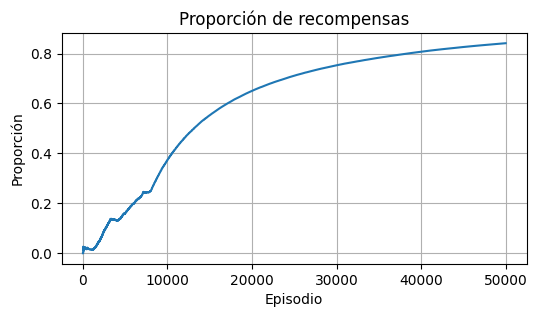

Máxima proporcion: 0.84124


In [8]:
#@title Proporción de aciertos por número de episodios

plot(list_stats)
print(f'Máxima proporcion: {list_stats[-1]}')

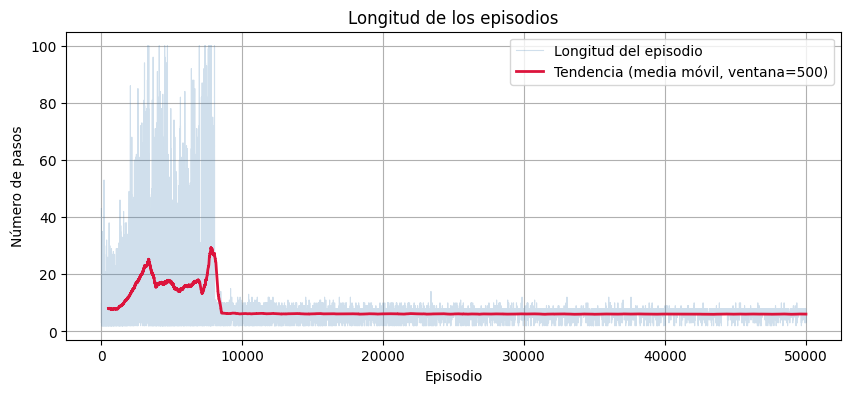

Longitud media final (últimos 1000 episodios): 6.08 pasos


In [9]:
#@title Longitud de episodios por número de episodio (4x4)

plot_lengths(list_lengths)
print(f'Longitud media final (últimos 1000 episodios): {np.mean(list_lengths[-1000:]):.2f} pasos')

####.
Mostramos los valores Q para cada estado. Cada estado tiene 4 valores, que se corresponden con las 4 acciones posibles.

In [10]:
# @title Tabla de valores Q
LEFT, DOWN, RIGHT, UP = 0,1,2,3
print('Valores Q para cada estado:\n', Q)

Valores Q para cada estado:
 [[0.99953978 0.99996616 0.99985906 0.9980936 ]
 [0.99952366 0.         0.99683716 0.86383875]
 [0.         0.96560545 0.63850489 0.        ]
 [1.         0.         0.         0.        ]
 [0.99799107 0.99997843 0.         0.99809732]
 [0.         0.         0.         0.        ]
 [0.         1.         0.         1.        ]
 [0.         0.         0.         0.        ]
 [0.99785673 0.         0.99997718 0.99802   ]
 [0.99785108 0.98993989 0.99997607 0.        ]
 [0.99750925 1.         0.         0.99167926]
 [0.         0.         0.         0.        ]
 [0.         0.         0.         0.        ]
 [0.         0.93600942 1.         1.        ]
 [0.99802366 0.99812401 1.         1.        ]
 [0.         0.         0.         0.        ]]


- También se muestra la política óptima (greedy) obtenida a partir del aprendizaje anterior.

- Cada estado tiene 4 valores, pero todos son 0 menos 1. Es decir, en cada estado se aplica de manera determinística una única acción.

- A continuación se visualiza el escenario 4x4 con las flechas de la política óptima superpuestas: cada celda libre (F) y la celda de salida (S) muestran la dirección que maximiza $Q(s,\cdot)$, mientras que los agujeros (H) y la meta (G) se identifican con su etiqueta y color característico.

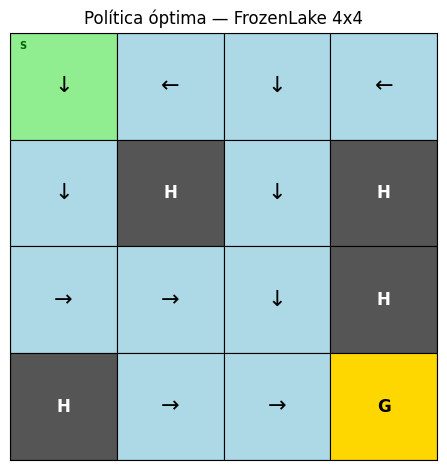

In [11]:
#@title Escenario con política óptima (4x4)
plot_scenario(env4, Q, title='Política óptima — FrozenLake 4x4')

In [12]:
# @title Política final
LEFT, DOWN, RIGHT, UP = 0,1,2,3
pi, actions = pi_star_from_Q(env4, Q)

print('Política óptima obtenida\n', pi, f'\n Acciones {actions} \n Para el siguiente grid\n', env4.render())
print()

Política óptima obtenida
 [[0. 1. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 1. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 2. 0.]
 [0. 0. 2. 0.]
 [0. 1. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 2. 0.]
 [0. 0. 0. 0.]] 
 Acciones 1, 1, 2, 2, 1, 2,  
 Para el siguiente grid
   (Right)
SFFF
FHFH
FFFH
HFFG




### **3.3 Experimentación en el escenario 8x8**

Se realizan 50 000 episodios con $\varepsilon$ con decaimiento y `q_init=0.01`.

**¿Por qué es necesario `q_init` en 8×8?**

Con `Q=0` al inicio, `np.argmax(Q[s])` devuelve siempre la **acción 0 (LEFT)** debido al desempate de numpy (primer índice máximo). En el 8×8 esto crea un sesgo crítico:

- La política de comportamiento $b$ toma LEFT con probabilidad $1-\varepsilon+\varepsilon/4 = 0.7$.
- Desde el estado inicial (0,0), LEFT rebota contra la pared → el agente queda atrapado en la esquina superior izquierda.
- Los episodios raramente alcanzan la meta en (7,7): la difusión efectiva hacia la derecha/abajo es $\leq 20\%$ de probabilidad por paso.
- Sin episodios exitosos, $Q$ no se actualiza, y el sesgo se perpetúa.

Con `q_init=0.01`, $Q$ se inicializa con valores aleatorios distintos en $[0, 0.01]$, por lo que la acción greedy varía por estado desde el inicio. Esto garantiza exploración diversa en los primeros episodios, necesaria para salir del área superior-izquierda y encontrar el primer camino hasta la meta. El valor 0.01 es despreciable respecto a los valores aprendidos ($Q \approx 1$), por lo que no sesga el aprendizaje posterior.

Este es el parámetro `q_init` del Algoritmo 6: *"Q(s,a) $\in \mathbb{R}$ (arbitrarily)"* — la inicialización aleatoria es válida y necesaria en entornos con recompensas dispersas.

In [13]:
# @title Aprendizaje
agent8 = MonteCarloOffPolicyAgent(env8, epsilon=0.4, decay=True, discount_factor=1, q_init=0.01)
list_stats, list_lengths = train(env8, agent8, num_episodes=50000)
Q = agent8.Q

 10%|█         | 5098/50000 [00:10<01:16, 590.66it/s]

success: 0.1434, epsilon: 0.2000


 20%|██        | 10094/50000 [00:21<00:54, 733.21it/s]

success: 0.4121, epsilon: 0.1000


 30%|███       | 15071/50000 [00:28<01:10, 496.54it/s]

...

success: 0.8088, epsilon: 0.0250


 90%|█████████ | 45152/50000 [01:09<00:05, 829.38it/s]

success: 0.8270, epsilon: 0.0222


100%|██████████| 50000/50000 [01:15<00:00, 664.38it/s]

success: 0.8419, epsilon: 0.0200


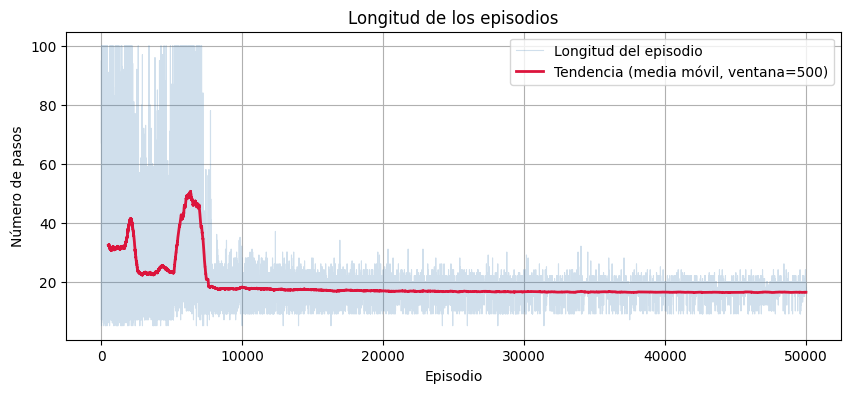

Longitud media final (últimos 1000 episodios): 16.36 pasos


In [14]:
#@title Longitud de episodios por número de episodio (8x8)

plot_lengths(list_lengths)
print(f'Longitud media final (últimos 1000 episodios): {np.mean(list_lengths[-1000:]):.2f} pasos')

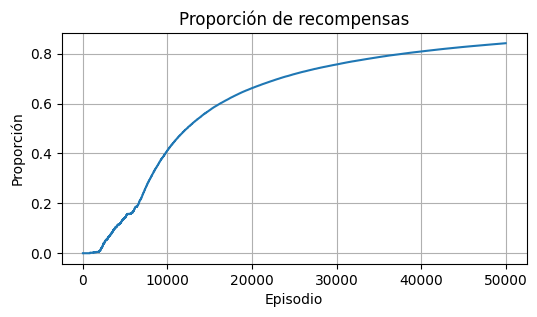

Máxima proporcion: 0.84192


In [15]:
#@title Proporción de aciertos por número de episodios

plot(list_stats)
print(f'Máxima proporcion: {list_stats[-1]}')

####.
Mostramos los valores Q para cada estado. Cada estado tiene 4 valores, que se corresponden con las 4 acciones posibles.

In [16]:
# @title Tabla de valores Q
LEFT, DOWN, RIGHT, UP = 0,1,2,3
print('Valores Q para cada estado:\n', Q)

Valores Q para cada estado:
 [[9.98249851e-01 1.00000000e+00 1.00000000e+00 1.00000000e+00]
 [1.00000000e+00 9.81973442e-01 9.98520382e-01 9.79363193e-01]
 [9.98272215e-01 9.98518863e-01 9.99930115e-01 9.98150826e-01]
 [9.98204137e-01 9.99448595e-01 9.99906096e-01 9.98213291e-01]
 [9.98170782e-01 9.99892007e-01 9.96629055e-01 9.98066498e-01]
 [9.45823191e-01 9.89315621e-01 9.99852907e-01 9.99842652e-01]
 [9.21031794e-01 9.99109564e-01 9.94648577e-01 9.54101241e-01]
 [8.85269331e-01 8.31141403e-01 0.00000000e+00 9.99319077e-01]
 [9.99448513e-01 9.96584106e-01 9.99951258e-01 9.98407520e-01]
 [9.97853633e-01 9.61689651e-01 9.99906174e-01 9.98208747e-01]
 [9.98012604e-01 9.96420307e-01 9.98151718e-01 9.99880130e-01]
 [8.73334108e-01 0.00000000e+00 9.83864686e-01 9.99486619e-01]
 [9.98240348e-01 9.99796681e-01 9.98223407e-01 9.98010081e-01]
 [9.46157100e-01 9.98656686e-01 9.88973367e-01 9.89478235e-01]
 [9.98867155e-01 9.95651812e-01 9.96431489e-01 9.35165969e-01]
 [8.14107082e-01 1.0000000

- También se muestra la política óptima (greedy) obtenida a partir del aprendizaje anterior.

- Cada estado tiene 4 valores, pero todos son 0 menos 1. Es decir, en cada estado se aplica de manera determinística una única acción.

- A continuación se visualiza el escenario 8x8 con las flechas de la política óptima superpuestas: cada celda libre (F) y la celda de salida (S) muestran la dirección que maximiza $Q(s,\cdot)$, mientras que los agujeros (H) y la meta (G) se identifican con su etiqueta y color característico.

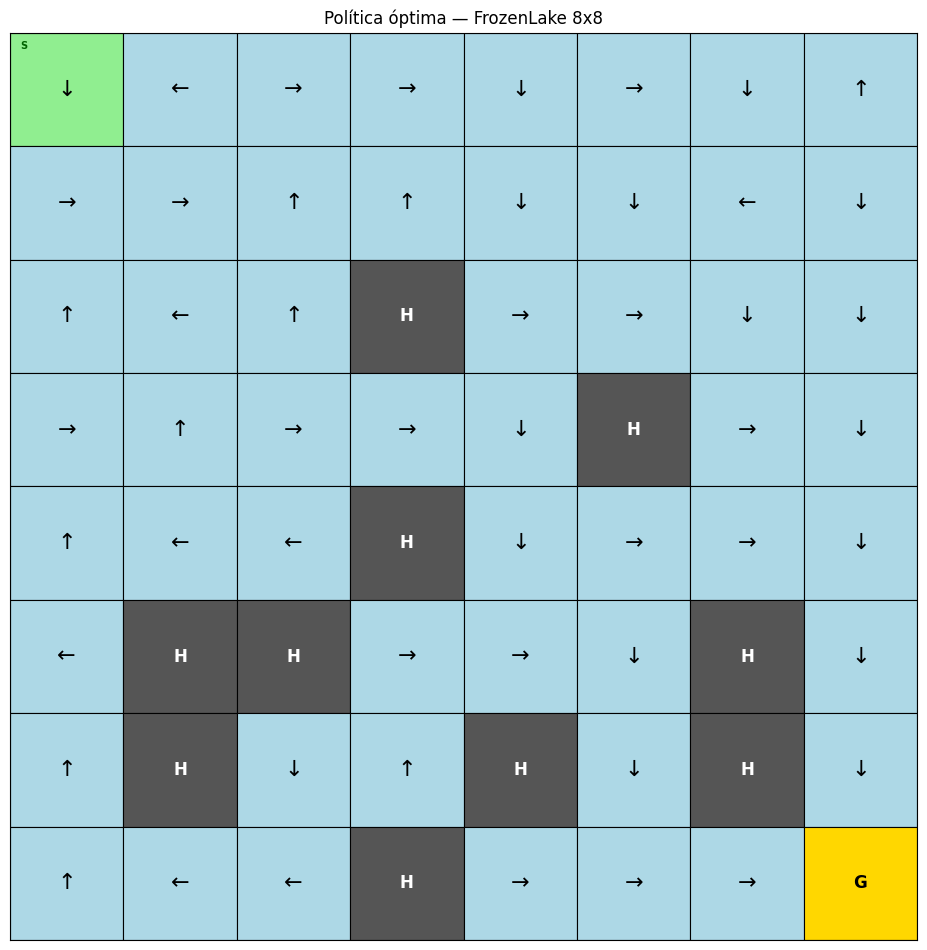

In [17]:
#@title Escenario con política óptima (8x8)
plot_scenario(env8, Q, title='Política óptima — FrozenLake 8x8')

In [18]:
# @title Política final
LEFT, DOWN, RIGHT, UP = 0,1,2,3
pi, actions = pi_star_from_Q(env8, Q)

print('Política óptima obtenida\n', pi, f'\n Acciones {actions} \n Para el siguiente grid\n', env8.render())
print()

Política óptima obtenida
 [[0. 1. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 2. 0.]
 [0. 0. 2. 0.]
 [0. 1. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 2. 0.]
 [0. 0. 2. 0.]
 [0. 0. 0. 3.]
 [0. 0. 0. 0.]
 [0. 1. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 2. 0.]
 [0. 0. 2. 0.]
 [0. 1. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 2. 0.]
 [0. 1. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 1. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 1. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 1. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]] 
 Acciones 1,

## **4. Análisis y Estudios Futuros**

### **4.1 Análisis de Resultados**

- El agente off-policy separa completamente la política de exploración ($b$) de la política que se mejora ($\pi$). Esto permite en principio reutilizar datos de cualquier política de comportamiento.

- La interrupción del bucle de retropropagación cuando $A_t \neq \arg\max Q[s]$ implica que en las primeras etapas del entrenamiento, con $\varepsilon$ alto, solo la **cola greedy** de cada episodio contribuye a las actualizaciones de Q. Esto ralentiza el aprendizaje inicial respecto al caso on-policy.

- Con decaimiento de $\varepsilon$, la política b se acerca a $\pi$, los pesos $W$ crecen hacia 1 y se reduce la varianza. El agente off-policy con decaimiento en 8x8 debería converger a tasas de éxito comparables al on-policy.

- El acumulador $C(s,a)$ actúa como denominador del IS ponderado. A diferencia del IS ordinario (divide por el número de visitas), el IS ponderado es sesgado pero tiene varianza mucho menor y es el método preferido en la práctica.

### **4.2 Propuestas para Estudios Futuros**

1. **Comparativa on-policy vs off-policy**: Ejecutar ambos agentes con los mismos hiperparámetros y semilla, y superponer sus curvas de tasa de éxito. ¿Cuántos episodios tarda más el off-policy en alcanzar la misma tasa?

2. **Efecto de $\varepsilon$ en la velocidad de convergencia**: Con $\varepsilon$ bajo, la política b es casi greedy y los pesos $W$ son cercanos a 1, pero la exploración es escasa. Con $\varepsilon$ alto, hay más exploración pero el bucle se interrumpe antes. ¿Existe un $\varepsilon$ óptimo para FrozenLake?

3. **IS ordinario vs IS ponderado**: Implementar la variante con IS ordinario y comparar la varianza de las estimaciones de Q.

4. **Política de comportamiento uniforme**: Usar una política aleatoria uniforme como $b$ (máxima exploración) y estudiar cómo afecta a la velocidad de aprendizaje y a la magnitud de los pesos $W$.